# MLP-044 — Scheduler

Воспроизводимый PyTorch MLP-эксперимент. Источник истины — модуль
`ml_project.mlp_experiments.mlp_044_scheduler`: в нём редактируются признаки, типы заполнения пропусков,
гиперпараметры и архитектура. Этот notebook загружает модуль, проверяет контракт,
выполняет честный внешний CV и сохраняет OOF-результаты.

Рабочий цикл: **одна гипотеза → изменение модуля → Restart Kernel → Run All → вывод**.

Внешний validation fold никогда не участвует в preprocessing, early stopping или
выборе эпохи. Внутри каждого outer train fold создаётся свой inner validation split.


## 1. Что редактировать

Открой `src/ml_project/mlp_experiments/mlp_044_scheduler.py`.

- `prepare_features(frame)` — только признаки, вычисляемые отдельно для каждой строки.
- `build_fold_transformer()` — обучаемые групповые признаки и статистики train fold.
- `numeric_features` и `categorical_features` — явные роли всех входов.
- `MLPTrainingConfig` — imputation, scaling, batch size, learning rate, epochs.
- `build_network(input_dim)` — любое строение на `nn.Module`, выдающее один логит на строку.

Если новый признак использует статистику нескольких строк — среднее, частоту,
группировку, target encoding — его нельзя заранее считать на всей таблице.
Создавайте его через `build_fold_transformer`: runtime отдельно вызовет `fit`
на train fold и `transform` на validation/test.


In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    p for p in (CURRENT_DIR, *CURRENT_DIR.parents)
    if (p / "README.md").is_file() and (p / "src").is_dir()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ml_project import DataCatalog
import ml_project.config as project_config
import ml_project.mlp_experiment as mlp_tools

EXPERIMENT_MODULE = 'ml_project.mlp_experiments.mlp_044_scheduler'
mlp_tools = importlib.reload(mlp_tools)
experiment_module = mlp_tools.load_mlp_experiment(EXPERIMENT_MODULE)
spec = experiment_module.EXPERIMENT

print("Project:", PROJECT_ROOT)
print("Experiment:", spec.experiment_id, spec.title)
print("Module:", EXPERIMENT_MODULE)
print("Hypothesis:", spec.hypothesis)
print("Controlled change:", spec.change_description)
print("Reference:", spec.parent_mlp_module or spec.sklearn_reference_module or "logistic baseline")
display(pd.Series(vars(spec.training), name="value").to_frame())


Project: D:\Projects\Titanik-ML-project
Experiment: MLP-044 Scheduler
Module: ml_project.mlp_experiments.mlp_044_scheduler
Hypothesis: CHANGE ME — if ..., then ..., because ...
Controlled change: CHANGE ME — exactly one controlled change
Reference: ml_project.mlp_experiments.mlp_024_dpoutmedium


,value
numeric_imputer,median
categorical_imputer,most_frequent
numeric_scaler,standard
batch_size,32
learning_rate,0.001
weight_decay,0.0
max_epochs,100
patience,12
min_delta,0.0001
inner_validation_fraction,0.15


## 2. Данные и feature contract

`prepare_features` вызывается отдельно для train и inference. Исходные таблицы
должны остаться неизменными, порядок строк, key и target сохраняются.
Заполнение пропусков и one-hot здесь ещё не выполняются — они fit-ятся внутри folds.


In [2]:
catalog = DataCatalog(PROJECT_ROOT, project_config.RAW_DIR, project_config.DATASETS)
catalog.validate()
raw_train = catalog.load(project_config.TRAIN_DATASET)
raw_test = catalog.load(project_config.INFERENCE_DATASET)
train_snapshot = raw_train.copy(deep=True)
test_snapshot = raw_test.copy(deep=True)

prepared = experiment_module.prepare_features(raw_train.copy(deep=True))
prepared_test = experiment_module.prepare_features(raw_test.copy(deep=True))
pd.testing.assert_frame_equal(raw_train, train_snapshot)
pd.testing.assert_frame_equal(raw_test, test_snapshot)
mlp_tools.validate_feature_data(
    prepared, raw_train, target=project_config.TARGET, key=project_config.KEY,
)

if project_config.TARGET in prepared_test.frame:
    raise ValueError("Inference data must not acquire target")
if not prepared_test.frame.index.equals(raw_test.index):
    raise ValueError("prepare_features changed inference row index/order")
if prepared.numeric_features != prepared_test.numeric_features:
    raise ValueError("Train/test numeric feature declarations differ")
if prepared.categorical_features != prepared_test.categorical_features:
    raise ValueError("Train/test categorical feature declarations differ")
missing_test = [
    name for name in prepared.features
    if name not in prepared_test.frame and name not in prepared.fold_generated_features
]
if missing_test:
    raise KeyError(f"Inference is missing features: {missing_test}")

feature_report = pd.DataFrame({
    "role": ["numeric"] * len(prepared.numeric_features)
            + ["categorical"] * len(prepared.categorical_features),
    "feature": list(prepared.features),
}).set_index("feature")
train_feature_view = prepared.frame.reindex(columns=list(prepared.features))
test_feature_view = prepared_test.frame.reindex(columns=list(prepared.features))
feature_report["dtype"] = train_feature_view.dtypes.astype(str)
feature_report["missing_train"] = train_feature_view.isna().sum()
feature_report["missing_test"] = test_feature_view.isna().sum()
display(feature_report)
display(
    prepared.frame.reindex(
        columns=[project_config.KEY, *prepared.features, project_config.TARGET]
    ).head()
)


,role,dtype,missing_train,missing_test
feature,,,,
Age,numeric,float64,177,86
TicketGroupSize,numeric,float64,891,418
FarePerPerson,numeric,float64,891,418
Embarked,categorical,str,2,0
FamilySizeGroup,categorical,string,0,0
IsnotAlone,categorical,float64,891,418
CabinKnown,categorical,int64,0,0
Deck,categorical,str,0,0
SexPclass,categorical,string,0,0


,PassengerId,Age,TicketGroupSize,FarePerPerson,Embarked,FamilySizeGroup,IsnotAlone,CabinKnown,Deck,SexPclass,Survived
0,1,22.0,NaN,NaN,S,2,NaN,0,FG_Unknown,male_P3,0
1,2,38.0,NaN,NaN,C,2,NaN,1,ABC,female_P1,1
2,3,26.0,NaN,NaN,S,1,NaN,0,FG_Unknown,female_P3,1
3,4,35.0,NaN,NaN,S,2,NaN,1,ABC,female_P1,1
4,5,35.0,NaN,NaN,S,1,NaN,0,FG_Unknown,male_P3,0


## 3. Preview preprocessing и сети

Preview нужен для формы и количества параметров. Официальные метрики ниже заново
создают и fit-ят preprocessing только на train-части каждого fold.


In [3]:
preview_transformer_builder = getattr(experiment_module, "build_fold_transformer", None)
preview_transformer = preview_transformer_builder() if preview_transformer_builder else None
preview_frame = prepared.frame.copy(deep=True)
if preview_transformer is not None:
    preview_transformer.fit(preview_frame)
    preview_frame = preview_transformer.transform(preview_frame)
preview_preprocessor = mlp_tools.build_preprocessor(prepared, spec.training)
preview_x = preview_preprocessor.fit_transform(
    preview_frame.loc[:, list(prepared.features)]
)
input_dim = preview_x.shape[1]
preview_model = experiment_module.build_network(input_dim)
parameter_count = sum(p.numel() for p in preview_model.parameters() if p.requires_grad)
print("Raw features:", len(prepared.features))
print("Inputs after preprocessing:", input_dim)
print("Trainable parameters:", parameter_count)
print(preview_model)


Raw features: 9
Inputs after preprocessing: 29
Trainable parameters: 1041
Sequential(
  (0): Linear(in_features=29, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=16, bias=True)
  (5): ReLU()
  (6): Dropout(p=0.2, inplace=False)
  (7): Linear(in_features=16, out_features=1, bias=True)
)


## 4. Outer CV

Каждый outer fold создаёт новый preprocessor и новую сеть. Внутри outer-train
выделяется inner validation только для early stopping. OOF-предсказание каждой
строки сделано моделью, которая эту строку не видела.


In [4]:
result = mlp_tools.run_mlp_cv(
    prepared,
    target=project_config.TARGET,
    key=project_config.KEY,
    build_network=experiment_module.build_network,
    spec=spec,
    build_fold_transformer=getattr(experiment_module, "build_fold_transformer", None),
)
display(result.fold_metrics.round(4))
display(result.summary.round(4))
print("Encoded input dimensions by fold:", result.input_dims)


,fold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,log_loss
0,1,0.8547,0.8251,0.9057,0.6957,0.7869,0.9128,0.3800
1,2,0.8371,0.8233,0.8000,0.7647,0.7820,0.8794,0.4007
2,3,0.8202,0.7928,0.8214,0.6765,0.7419,0.8596,0.4405
3,4,0.8315,0.8159,0.7969,0.7500,0.7727,0.8745,0.3958
4,5,0.8146,0.7954,0.7903,0.7101,0.7481,0.8642,0.4174


,mean,std,min,max
accuracy,0.8316,0.0157,0.8146,0.8547
balanced_accuracy,0.8105,0.0154,0.7928,0.8251
precision,0.8229,0.0477,0.7903,0.9057
recall,0.7194,0.0370,0.6765,0.7647
f1,0.7663,0.0202,0.7419,0.7869
roc_auc,0.8781,0.0210,0.8596,0.9128
log_loss,0.4069,0.0231,0.3800,0.4405


Encoded input dimensions by fold: {1: 29, 2: 29, 3: 29, 4: 29, 5: 29}


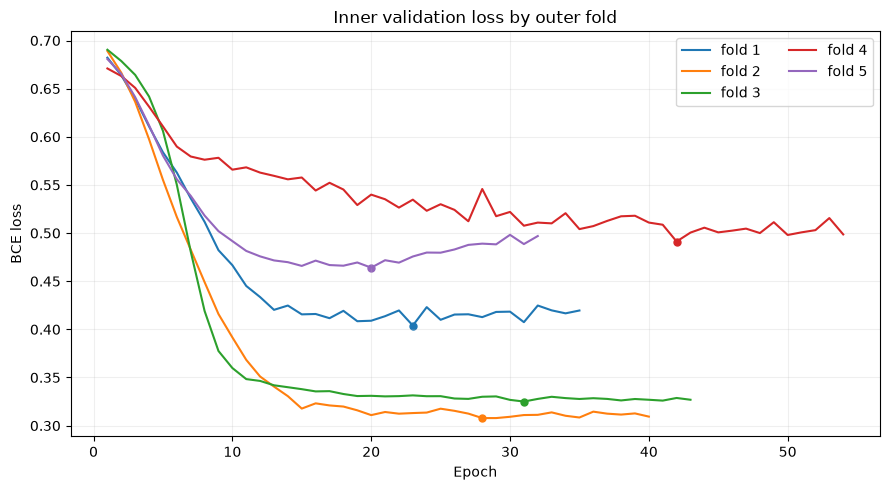

In [5]:
figure = mlp_tools.plot_training_histories(result)
display(figure)
plt.close(figure)


## 5. Reference champion и paired-сравнение

Reference заново обучается на тех же outer folds. Для первого MLP это последний
принятый sklearn-чемпион; для следующих опытов — последний MLP с
`decision: adopt`. Положительный `improvement` всегда означает улучшение,
включая `log_loss`, где меньше — лучше.


In [6]:
if spec.parent_mlp_module:
    reference = mlp_tools.run_mlp_parent_reference(
        raw_train,
        module_name=spec.parent_mlp_module,
        target=project_config.TARGET,
        key=project_config.KEY,
        cv_splits=result.cv_splits,
    )
else:
    reference = mlp_tools.run_sklearn_champion_reference(
        PROJECT_ROOT,
        raw_train,
        module_name=spec.sklearn_reference_module,
        target=project_config.TARGET,
        key=project_config.KEY,
        feature_groups=project_config.FEATURE_GROUPS,
        cv_splits=result.cv_splits,
    )

comparison = mlp_tools.compare_mlp_with_reference(result, reference, spec)
display(comparison.summary.round(4))
display(comparison.criteria.round(4))
display(
    comparison.paired_deltas[
        comparison.paired_deltas["metric"].eq(spec.primary_metric)
    ].round(4)
)


,model,metric,mean,std,min,max
0,MLP-024_reference,accuracy,0.8384,0.0111,0.8258,0.8547
1,MLP-024_reference,balanced_accuracy,0.8176,0.0111,0.8019,0.8278
2,MLP-024_reference,precision,0.8324,0.0394,0.7969,0.8909
3,MLP-024_reference,recall,0.7281,0.0351,0.6765,0.7647
4,MLP-024_reference,f1,0.7756,0.0148,0.7541,0.7903
5,MLP-024_reference,roc_auc,0.8780,0.0215,0.8592,0.9140
6,MLP-024_reference,log_loss,0.4058,0.0244,0.3786,0.4403
7,mlp_candidate,accuracy,0.8316,0.0157,0.8146,0.8547
8,mlp_candidate,balanced_accuracy,0.8105,0.0154,0.7928,0.8251
9,mlp_candidate,precision,0.8229,0.0477,0.7903,0.9057


,role,metric,observed_improvement,minimum_improvement,passed
0,primary,accuracy,-0.0067,0.00,False
1,guardrail,balanced_accuracy,-0.0071,0.00,False
2,guardrail,recall,-0.0087,-0.01,True
3,guardrail,f1,-0.0093,0.00,False


,fold,metric,reference,candidate,improvement
0,1,accuracy,0.8547,0.8547,0.0000
1,2,accuracy,0.8371,0.8371,0.0000
2,3,accuracy,0.8315,0.8202,-0.0112
3,4,accuracy,0.8427,0.8315,-0.0112
4,5,accuracy,0.8258,0.8146,-0.0112


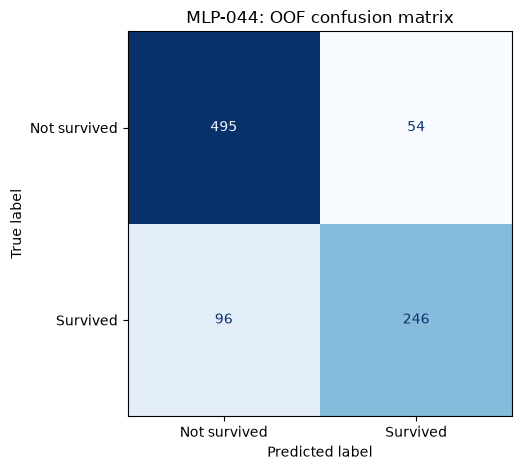

,rows,accuracy,mean_probability
Sex,,,
female,314.0,0.828025,0.754568
male,577.0,0.833622,0.190274


,PassengerId,Sex,Pclass,Name,fold,target,probability,prediction,confidence
297,298,female,1,"Allison, Miss. Helen Loraine",5,0,0.991852,1,0.991852
498,499,female,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",1,0,0.970714,1,0.970714
177,178,female,1,"Isham, Miss. Ann Elizabeth",1,0,0.966790,1,0.966790
570,571,male,2,"Harris, Mr. George",3,1,0.035837,0,0.964163
312,313,female,2,"Lahtinen, Mrs. William (Anna Sylfven)",3,0,0.958939,1,0.958939
199,200,female,2,"Yrois, Miss. Henriette (""Mrs Harbeck"")",4,0,0.954766,1,0.954766
772,773,female,2,"Mack, Mrs. (Mary)",2,0,0.954657,1,0.954657
205,206,female,3,"Strom, Miss. Telma Matilda",3,0,0.937111,1,0.937111
414,415,male,3,"Sundman, Mr. Johan Julian",2,1,0.064771,0,0.935229
338,339,male,3,"Dahl, Mr. Karl Edwart",4,1,0.066378,0,0.933622


Исправлено ошибок reference: 3
Добавлено новых ошибок: 9


In [7]:
oof = result.oof_predictions
ConfusionMatrixDisplay.from_predictions(
    oof["target"], oof["prediction"], labels=[0, 1],
    display_labels=["Not survived", "Survived"], cmap="Blues", colorbar=False,
)
plt.title(f"{spec.experiment_id}: OOF confusion matrix")
plt.tight_layout()
plt.show()

analysis = raw_train[[project_config.KEY, "Sex", "Pclass", "Name"]].merge(
    oof, on=project_config.KEY, validate="one_to_one"
)
segment_metrics = analysis.groupby("Sex", observed=True).apply(
    lambda part: pd.Series({
        "rows": len(part),
        "accuracy": (part["target"] == part["prediction"]).mean(),
        "mean_probability": part["probability"].mean(),
    }),
    include_groups=False,
)
display(segment_metrics)
display(
    analysis.assign(confidence=lambda x: np.maximum(x.probability, 1-x.probability))
    .query("target != prediction")
    .sort_values("confidence", ascending=False)
    .head(15)
)

candidate_oof = result.oof_predictions.set_index(project_config.KEY)
reference_oof = reference.oof_predictions.set_index(project_config.KEY)
error_changes = candidate_oof[["target", "prediction", "probability"]].join(
    reference_oof[["prediction", "probability"]].rename(columns={
        "prediction": "reference_prediction",
        "probability": "reference_probability",
    }),
    validate="one_to_one",
)
print("Исправлено ошибок reference:", int((
    (error_changes.prediction == error_changes.target)
    & (error_changes.reference_prediction != error_changes.target)
).sum()))
print("Добавлено новых ошибок:", int((
    (error_changes.prediction != error_changes.target)
    & (error_changes.reference_prediction == error_changes.target)
).sum()))


## 6. Вывод до финального fit

- Гипотеза подтвердилась / не подтвердилась: …
- Основная OOF-метрика, paired Δ и fold wins/losses: …
- Что видно по train curves: …
- Ошибки по мужчинам и женщинам: …
- Единственное изменение следующего эксперимента: …

Не подбирайте архитектуру по Kaggle test: там нет target. Новый набор признаков,
imputer, hidden layer, dropout или learning rate оформляйте новым `MLP-xxx`.


## 7. Сохранить результат и Obsidian-карточку

Сохраняются fold metrics, OOF, paired Δ, история эпох и hashes. Затем создаются
карточка `mlp-experiments/MLP-xxx ...md`, CSV-реестр, индекс и блок в README.
Ручной анализ карточки и поле `decision` при перезапуске сохраняются.


In [8]:
run_dir = None
if spec.save_artifacts:
    dataset_path = catalog.path(project_config.TRAIN_DATASET)
    run_dir = mlp_tools.save_mlp_run(
        PROJECT_ROOT, experiment_module, prepared, result,
        target=project_config.TARGET, key=project_config.KEY,
        dataset_path=dataset_path,
        comparison=comparison,
    )
    print("Artifacts:", run_dir.relative_to(PROJECT_ROOT))
    if spec.sync_docs:
        note_path = mlp_tools.sync_mlp_report(
            PROJECT_ROOT,
            experiment_module,
            prepared,
            result,
            comparison,
            run_dir,
            dataset_path=dataset_path,
        )
        print("Obsidian card:", note_path.relative_to(PROJECT_ROOT))
else:
    print("Artifact saving is disabled in EXPERIMENT.")


Artifacts: artifacts\mlp-experiments\MLP-044\3ec42e5a2874
Obsidian card: mlp-experiments\MLP-044 Scheduler.md


## 8. Финальная модель и Kaggle preview

Финальная сеть обучается на всей размеченной таблице; внутри неё остаётся inner
split для выбора эпохи. Это отдельный fit после оценки CV. `SAVE_FINAL_MODEL`
управляет записью весов, preprocessor и CSV. Сначала изучите CV и только затем
включайте сохранение.


In [9]:
SAVE_FINAL_MODEL = False

if SAVE_FINAL_MODEL:
    if run_dir is None:
        raise RuntimeError("Enable spec.save_artifacts before final model saving")
    final_model = mlp_tools.fit_final_mlp(
        prepared,
        target=project_config.TARGET,
        build_network=experiment_module.build_network,
        spec=spec,
        build_fold_transformer=getattr(experiment_module, "build_fold_transformer", None),
    )
    test_probability = mlp_tools.predict_prepared_mlp(final_model, prepared_test)
    submission = pd.DataFrame({
        project_config.KEY: prepared_test.frame[project_config.KEY].to_numpy(),
        project_config.TARGET: (
            test_probability >= spec.training.threshold
        ).astype("int64"),
    })
    if len(submission) != len(raw_test) or not submission[project_config.KEY].equals(raw_test[project_config.KEY]):
        raise ValueError("Submission row/key contract failed")
    mlp_tools.save_final_mlp(run_dir, final_model)
    submission.to_csv(run_dir / "submission.csv", index=False)
    pd.DataFrame({
        project_config.KEY: prepared_test.frame[project_config.KEY],
        "probability": test_probability,
    }).to_csv(run_dir / "test_probabilities.csv", index=False)
    display(submission.head())
    print("Final model and submission saved to:", run_dir.relative_to(PROJECT_ROOT))
else:
    print("Final fit is disabled. Set SAVE_FINAL_MODEL = True after accepting CV result.")


Final fit is disabled. Set SAVE_FINAL_MODEL = True after accepting CV result.


## 9. Решение и следующий эксперимент

После анализа измените в карточке только `decision:` на `adopt`, `reject`,
`iterate` или `inconclusive`, затем выполните:

```powershell
.\sync-MLPexperiment-state.cmd
```

Из корня проекта:

```powershell
.\new-MLPexperiment.cmd
```

Команда создаст следующий `MLP-xxx`, отдельный модуль и notebook. Старый модуль
после измеренного запуска не редактируйте: он фиксирует точное определение опыта.
